In [9]:
# Merging datasets

import csv

label = []
comment = []

with open("reddit.csv", "r") as f :
    reader = csv.reader(f)
    reader.__next__()
    for row in reader : 
        label.append(row[0])
        comment.append(row[1])



with open("tweets.csv", "r") as g :
    reader = csv.reader(g) 
    reader.__next__()
    for row in reader : 
        if row[1] == "figurative" or row[1] == "sarcasm" :
            label.append(1)
        else : 
            label.append(0)

        comment.append(row[0])


data = zip(comment,label)

with open("merged_data.csv", "w") as k : 
    writer = csv.writer(k, delimiter = ",")
    writer.writerow(["comment", "label"])
    writer.writerows(data)

In [16]:
# Extract punctuation features

import re
import csv

with open("reddit_with_features.csv", "w") as g:
    writer = csv.writer(g)
    writer.writerow(["comment", "label", "!", "?", "...", "capital letter", '"'])
    with open("merged_data.csv", "r") as f : 
        reader = csv.reader(f)
        reader.__next__()
        for row in reader :
            comment = row[0]
            label = row[1]
            exclamation = comment.count('!')
            question = comment.count("?")
            ellipses = len(re.findall(r'\.\.\.', comment))
            capital = sum(1 for char in comment if char.isupper())
            quotation = comment.count('"')
            
            writer.writerow(
                [comment,
                 label,
                 exclamation,
                 question, 
                 ellipses, 
                 capital, 
                 quotation])



In [18]:
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import RobertaTokenizerFast
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 

df_full = pd.read_csv("reddit_with_features.csv")
# print(len(df_full))

df = df_full.sample(n=15000, random_state=42).reset_index(drop=True)


train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

feature_cols = ["!", "?", "...", "capital letter", '"']
scaler = StandardScaler()

train_features = scaler.fit_transform(train_df[feature_cols])
test_features = scaler.transform(test_df[feature_cols])

tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

train_encodings = tokenizer(
    train_df['comment'].astype(str).tolist(), 
    truncation=True, padding='max_length', max_length=128, return_tensors='pt'
)

test_encodings = tokenizer(
    test_df['comment'].astype(str).tolist(), 
    truncation=True, padding='max_length', max_length=128, return_tensors='pt'
)


train_features_tensor = torch.tensor(train_features, dtype=torch.float)
train_labels_tensor = torch.tensor(train_df['label'].values, dtype=torch.long)

test_features_tensor = torch.tensor(test_features, dtype=torch.float)
test_labels_tensor = torch.tensor(test_df['label'].values, dtype=torch.long)

train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], train_features_tensor, train_labels_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], test_features_tensor, test_labels_tensor)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Train batches: {len(train_loader)} ({16 * len(train_loader)} rows) ")
print(f"Test batches:  {len(test_loader)} ({16 * len(test_loader)} rows) \n")

Train batches: 750 (12000 rows) 
Test batches:  188 (3008 rows) 



In [19]:
# RoBERTa Model

import torch.nn as nn
from transformers import RobertaModel
import torch.nn.functional as F

class RobertaWithFeatures(nn.Module):
    def __init__(self, num_extra_features, num_classes=2):
        super(RobertaWithFeatures, self).__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        
        combined_dim = self.roberta.config.hidden_size + num_extra_features
        self.drop = nn.Dropout(p=0.5)
        self.classifier = nn.Linear(combined_dim, num_classes)

    def forward(self, input_ids, attention_mask, extra_features):
        roberta_output = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.drop(roberta_output.pooler_output)
        
        combined_features = torch.cat((pooled_output, extra_features), dim=1)
        return self.classifier(combined_features)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Device: Apple Silicon GPU (MPS)")
else:
    device = torch.device("cpu")
    print("Device: CPU")

model = RobertaWithFeatures(num_extra_features=5).to(device)
model.float() 

for name, param in model.roberta.named_parameters():
    if any(f"layer.{i}." in name for i in range(8)):
        param.requires_grad = False

Device: Apple Silicon GPU (MPS)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
epochs = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

import gc
gc.collect()
torch.mps.empty_cache()
print("MPS cache cleared")

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=100,
    num_training_steps=len(train_loader) * epochs
)

best_val_loss = float('inf')
patience = 2
epochs_no_improve = 0

print("\nStarting training loop")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for i, batch in enumerate(train_loader):
        
        b_input_ids, b_attn_mask, b_features, b_labels = batch
        
        input_ids = b_input_ids.to(device)
        attention_mask = b_attn_mask.to(device)
        extra_features = b_features.to(device)
        batch_labels = b_labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, extra_features=extra_features)
        loss = F.cross_entropy(outputs, batch_labels)
            
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
        
        if i % 50 == 0:
            print(f"  -> Processed batch {i} out of {len(train_loader)}...")
            
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss) 
    print(f"*** Epoch {epoch+1}/{epochs} Complete | Average Training Loss: {avg_loss:.4f} ***\n")


    model.eval()
    val_loss = 0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in test_loader:
            b_input_ids, b_attn_mask, b_features, b_labels = batch

            input_ids = b_input_ids.to(device)
            attention_mask = b_attn_mask.to(device)
            extra_features = b_features.to(device)
            batch_labels = b_labels.to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, extra_features=extra_features)
            loss = F.cross_entropy(outputs, batch_labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, dim=1)
            correct_predictions += torch.sum(preds == batch_labels)
            total_predictions += batch_labels.size(0)

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss) 
    val_accuracy = correct_predictions.float() / total_predictions

    train_accuracies.append(avg_loss)  
    val_accuracies.append(val_accuracy.item())
    print(f"*** Epoch {epoch+1} Validation | Loss: {avg_val_loss:.4f} | Accuracy: {val_accuracy:.4f} ***\n")

   
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pt")
        epochs_no_improve = 0
        print(f"  -> Validation loss improved, model saved.\n")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement ({epochs_no_improve}/{patience})\n")
        if epochs_no_improve >= patience:
            print("Early stopping triggered — loading best model.")
            model.load_state_dict(torch.load("best_model.pt"))
            break

MPS cache cleared

Starting training loop
  -> Processed batch 0 out of 750...
  -> Processed batch 50 out of 750...
  -> Processed batch 100 out of 750...
  -> Processed batch 150 out of 750...
  -> Processed batch 200 out of 750...
  -> Processed batch 250 out of 750...
  -> Processed batch 300 out of 750...
  -> Processed batch 350 out of 750...
  -> Processed batch 400 out of 750...
  -> Processed batch 450 out of 750...
  -> Processed batch 500 out of 750...
  -> Processed batch 550 out of 750...
  -> Processed batch 600 out of 750...
  -> Processed batch 650 out of 750...
  -> Processed batch 700 out of 750...
*** Epoch 1/5 Complete | Average Training Loss: 0.6461 ***

*** Epoch 1 Validation | Loss: 0.5654 | Accuracy: 0.7167 ***

  -> Validation loss improved, model saved.

  -> Processed batch 0 out of 750...
  -> Processed batch 50 out of 750...
  -> Processed batch 100 out of 750...
  -> Processed batch 150 out of 750...
  -> Processed batch 200 out of 750...
  -> Processed ba

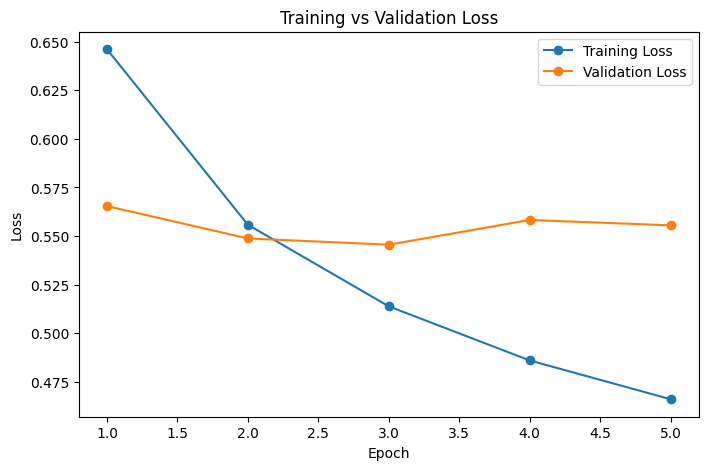

In [21]:
# FIGURE 2: Training loss curve
import matplotlib.pyplot as plt

# After training, plot both:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label='Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

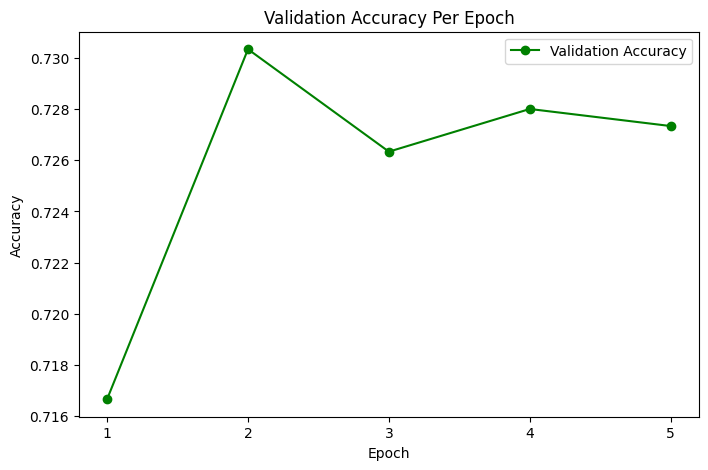

In [22]:
# FIGURE 3 : Validation
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(val_accuracies)+1), val_accuracies, marker='o', color='green', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Per Epoch')
plt.xticks(range(1, len(val_accuracies)+1))
plt.legend()
plt.savefig('val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Testing on testset

model.eval()

val_loss = 0
correct_predictions = 0
total_predictions = 0
wrong_predictions = []
all_labels = []
all_preds = []

test_comments = test_df['comment'].astype(str).tolist()
test_offset = 0

with torch.no_grad(): 
        for batch in test_loader:
            b_input_ids, b_attn_mask, b_features, b_labels = batch
            
            input_ids = b_input_ids.to(device)
            attention_mask = b_attn_mask.to(device)
            extra_features = b_features.to(device)
            batch_labels = b_labels.to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, extra_features=extra_features)
            
            loss = F.cross_entropy(outputs, batch_labels)
            val_loss += loss.item()
            
            # Calculate how many it got right
            _, preds = torch.max(outputs, dim=1)
            correct_predictions += torch.sum(preds == batch_labels)
            total_predictions += batch_labels.size(0)

            all_labels.extend(batch_labels.cpu().numpy()) 
            all_preds.extend(preds.cpu().numpy())    

            batch_size = batch_labels.size(0)
            for j in range(batch_size):
                if preds[j] != batch_labels[j]:
                    wrong_predictions.append({
                        "comment":   test_comments[test_offset + j],
                        "actual":    "sarcastic" if batch_labels[j].item() == 1 else "not sarcastic",
                        "predicted": "sarcastic" if preds[j].item() == 1 else "not sarcastic"
                    })
            test_offset += batch_size
            
avg_val_loss = val_loss / len(test_loader)
val_accuracy = correct_predictions.float() / total_predictions
    
print(f"*** Validation | Loss: {avg_val_loss:.4f} | Accuracy: {val_accuracy * 100 :.4f}% ***\n")
print(f"Total mistakes: {len(wrong_predictions)} out of {total_predictions}\n")


*** Validation | Loss: 0.5455 | Accuracy: 72.6333% ***

Total mistakes: 821 out of 3000



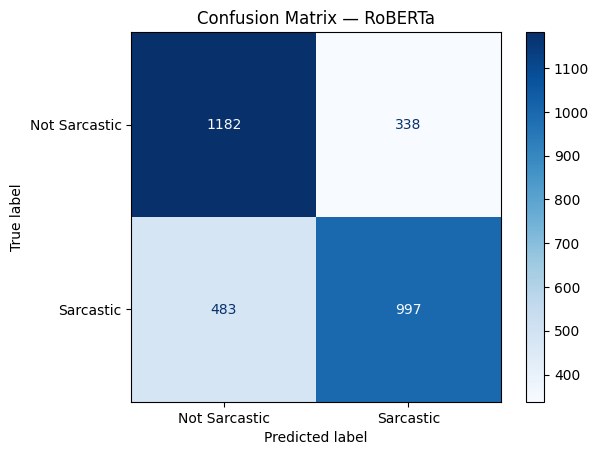

In [24]:
# FIGURE 4: Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Sarcastic', 'Sarcastic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — RoBERTa')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

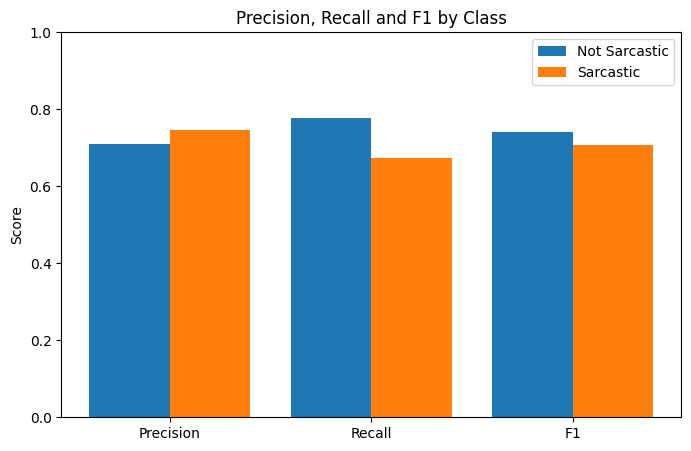

In [25]:
# FIGURE 5: Precision, Recall, F1 bar chart
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)
metrics = ['Precision', 'Recall', 'F1']
not_sarcastic = [precision[0], recall[0], f1[0]]
sarcastic = [precision[1], recall[1], f1[1]]

x = range(len(metrics))
plt.figure(figsize=(8,5))
plt.bar([i - 0.2 for i in x], not_sarcastic, width=0.4, label='Not Sarcastic')
plt.bar([i + 0.2 for i in x], sarcastic, width=0.4, label='Sarcastic')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Precision, Recall and F1 by Class')
plt.legend()
plt.ylim(0, 1)
plt.savefig('precision_recall_f1.png', dpi=150, bbox_inches='tight')
plt.show()

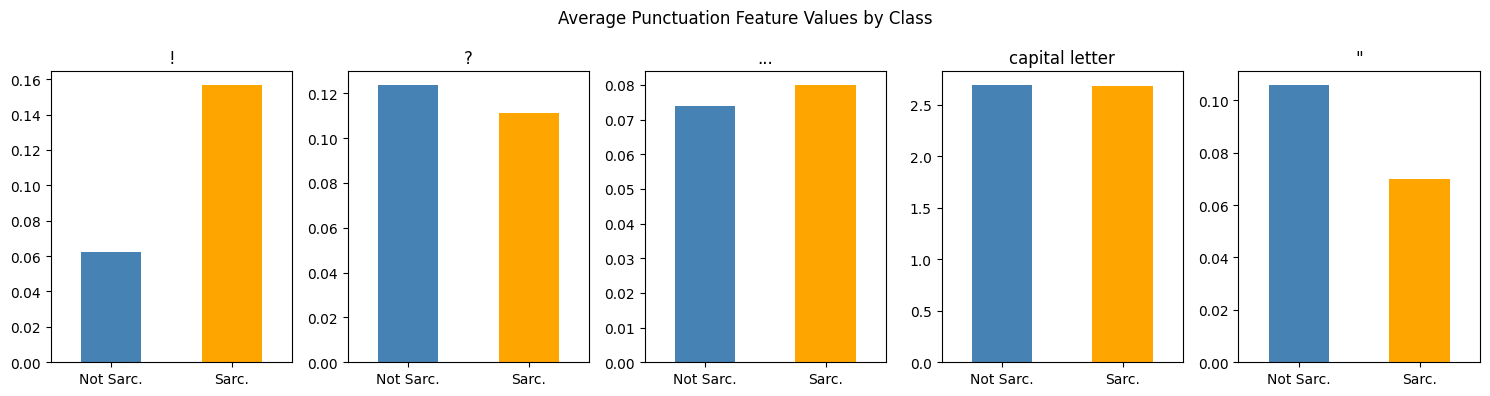

In [26]:
# FIGURE 6: Feature importance — show punctuation feature distributions
import seaborn as sns

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
feature_cols = ["!", "?", "...", "capital letter", '"']

for i, col in enumerate(feature_cols):
    df.groupby('label')[col].mean().plot(kind='bar', ax=axes[i], color=['steelblue', 'orange'])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Not Sarc.', 'Sarc.'], rotation=0)

plt.suptitle('Average Punctuation Feature Values by Class')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()